In [21]:
import matplotlib.pyplot as plt
# Importation de matplotlib.
# Cette bibliothèque sert à créer des graphiques
# afin de visualiser les données et les résultats du modèle.

Prédictions : [1 1]
Accuracy : 0.0


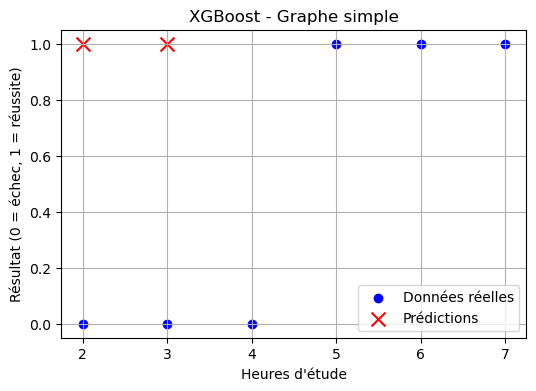

In [20]:
#L'algorithme XGBoost (Apprentissage supervise)
import numpy as np
# Importation de la bibliothèque numpy.
# Elle permet de manipuler facilement les données numériques
# sous forme de tableaux et de matrices.
# C’est une bibliothèque essentielle dans le machine learning
# car elle facilite les calculs mathématiques rapides.

from xgboost import XGBClassifier
# Importation du modèle XGBoost pour la classification.
# XGBoost est un algorithme très puissant basé sur les arbres de décision.
# Il est souvent utilisé dans les compétitions de data science
# grâce à sa précision élevée et sa rapidité.

from sklearn.model_selection import train_test_split
# Fonction utilisée pour séparer le dataset en deux parties :
# - une partie pour entraîner le modèle
# - une partie pour tester ses performances

from sklearn.metrics import accuracy_score
# Fonction utilisée pour mesurer la précision du modèle.
# Elle compare les prédictions avec les vraies réponses.

# ================================
# 1. Création du dataset
# ================================

X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 8]
])
# X représente les variables explicatives (features).
# Chaque ligne représente un étudiant.
# - colonne 1 : heures d’étude
# - colonne 2 : participation en classe
# Ces variables vont aider le modèle à prédire la réussite.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la variable cible (target).
# 0 → étudiant en échec
# 1 → étudiant réussi
# Le modèle va essayer d’apprendre la relation entre X et y.

# ================================
# 2. Séparation des données
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Division automatique des données :
# - 80% pour l’apprentissage
# - 20% pour le test
# Le modèle apprend sur X_train et y_train.
# Ensuite on teste ses performances sur X_test.
# random_state permet d’obtenir toujours le même découpage.

# ================================
# 3. Création du modèle XGBoost
# ================================

model = XGBClassifier(
    n_estimators=10,
    max_depth=3,
    learning_rate=0.1
)
# n_estimators :
# nombre d’arbres de décision utilisés dans le modèle.
# Plus il y a d’arbres, plus le modèle peut devenir performant.

# max_depth :
# profondeur maximale des arbres.
# Une profondeur trop grande peut provoquer du surapprentissage.

# learning_rate :
# vitesse d’apprentissage.
# Une petite valeur rend l’apprentissage plus stable.

# ================================
# 4. Entraînement du modèle
# ================================

model.fit(X_train, y_train)
# Le modèle analyse les données d’entraînement.
# Il apprend automatiquement les relations entre les variables.
# L’objectif est de minimiser les erreurs de prédiction.

# ================================
# 5. Prédictions
# ================================

predictions = model.predict(X_test)
# Le modèle utilise les données de test pour faire des prédictions.
# Il retourne ici des classes :
# 0 ou 1.

print("Prédictions :", predictions)

# ================================
# 6. Évaluation des performances
# ================================

accuracy = accuracy_score(y_test, predictions)
# Calcul de l’accuracy :
# Accuracy = nombre de bonnes prédictions / nombre total.
# Plus la valeur est proche de 1, meilleur est le modèle.

print("Accuracy :", accuracy)


# ================================
# 7. Graphe 
# ================================

plt.figure(figsize=(6,4))

# Affichage des données réelles
plt.scatter(X[:,0], y, color="blue", label="Données réelles")
# X[:,0] = première variable (heures d'étude)
# y = classes réelles (0 ou 1)
# On utilise des points bleus pour représenter les données originales

# Affichage des prédictions du modèle
plt.scatter(X_test[:,0], predictions, color="red", marker="x", s=100, label="Prédictions")
# Points rouges en forme de "x" pour montrer les prédictions du modèle

# Légendes et titres
plt.xlabel("Heures d'étude")
# Axe X : variable explicative principale

plt.ylabel("Résultat (0 = échec, 1 = réussite)")
# Axe Y : classe réelle ou prédite

plt.title("XGBoost - Graphe simple")
# Titre du graphique

plt.legend()
# Affiche la légende pour distinguer les données

plt.grid(True)
# Ajoute une grille pour mieux lire le graphique

plt.show()
# Affiche le graphique final



Clusters : [ 0  0  0  1  1 -1]


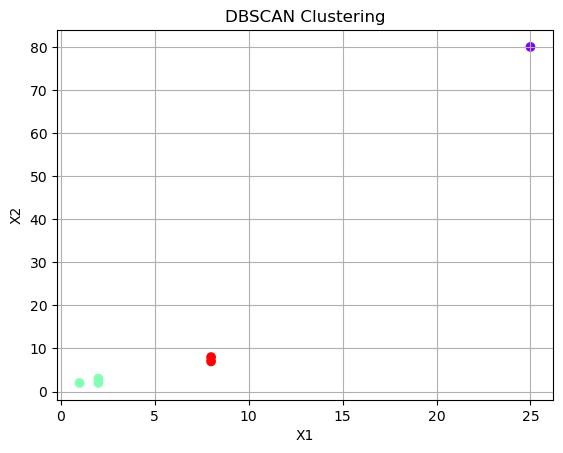

In [15]:
#DBSCAN (apprentissage non supervise)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
# Importation de l’algorithme DBSCAN.
# DBSCAN est un algorithme de clustering.
# Il regroupe automatiquement les données similaires
# sans utiliser de classes prédéfinies.

# ================================
# 1. Dataset
# ================================

X = np.array([
    [1, 2],
    [2, 2],
    [2, 3],
    [8, 7],
    [8, 8],
    [25, 80]
])
# Chaque ligne représente un point dans un espace 2D.
# Les points proches vont former des clusters.
# Le dernier point est très éloigné :
# il sera probablement considéré comme du bruit (noise).

# ================================
# 2. Création du modèle DBSCAN
# ================================

model = DBSCAN(eps=2, min_samples=2)
# eps :
# distance maximale entre deux voisins.
# Si deux points sont proches selon cette distance,
# ils peuvent appartenir au même cluster.

# min_samples :
# nombre minimal de voisins nécessaires
# pour former un cluster valide.

labels = model.fit_predict(X)
# fit_predict :
# - le modèle apprend automatiquement
# - puis il attribue un cluster à chaque point

print("Clusters :", labels)
# Affichage des clusters trouvés.
# -1 signifie généralement un bruit (noise).

# ================================
# 3. Visualisation des clusters
# ================================

plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
# Affichage des points.
# Chaque cluster possède une couleur différente.

plt.title("DBSCAN Clustering")
plt.xlabel("X1")
plt.ylabel("X2")

plt.grid(True)
plt.show()

Données réduites :
[[-3.46410162e+00  3.70835916e-16]
 [-1.73205081e+00 -1.23611972e-16]
 [ 0.00000000e+00 -0.00000000e+00]
 [ 1.73205081e+00  1.23611972e-16]
 [ 3.46410162e+00  2.47223944e-16]]


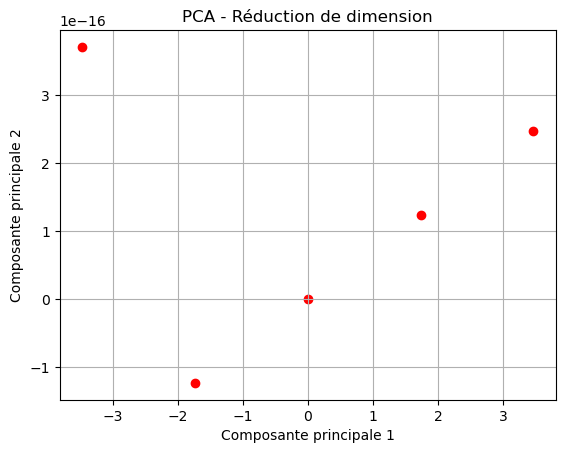

In [18]:
#L'algorithme PCA (Réduction de dimension)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
# Importation de l’algorithme PCA.
# PCA signifie Principal Component Analysis.
# Il sert à réduire le nombre de dimensions
# tout en conservant le maximum d’information.

# ================================
# 1. Dataset
# ================================

X = np.array([
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6],
    [5, 6, 7],
    [6, 7, 8]
])
# Dataset contenant 3 variables.
# Chaque ligne représente une observation.

# ================================
# 2. Réduction de dimension
# ================================

pca = PCA(n_components=2)
# On demande à PCA de réduire les données
# de 3 dimensions vers seulement 2 dimensions.

X_reduced = pca.fit_transform(X)
# PCA analyse les relations entre variables
# puis crée de nouvelles composantes principales
# contenant l’essentiel de l’information.

print("Données réduites :")
print(X_reduced)

# ================================
# 3. Visualisation
# ================================

plt.scatter(X_reduced[:,0], X_reduced[:,1], color='red')
# Affichage des données après réduction de dimension.
# Les données sont maintenant représentées en 2D.

plt.title("PCA - Réduction de dimension")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.grid(True)
plt.show()

Classe prédite : 1
Probabilités : [[3.1363713e-36 1.0000000e+00]]


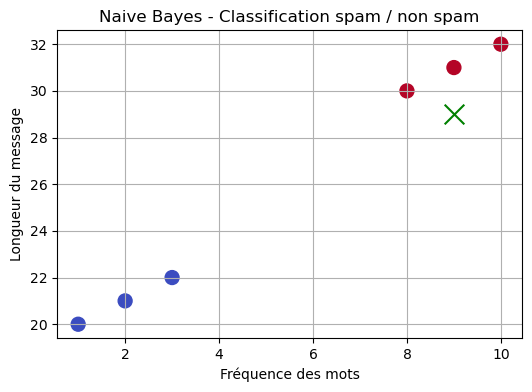

In [16]:
#Naive Bayes (apprentissage non supervise)
import numpy as np
# Importation de numpy.
# Cette bibliothèque permet de manipuler facilement
# les données numériques sous forme de tableaux.

from sklearn.naive_bayes import GaussianNB
# Importation du modèle Gaussian Naive Bayes.
# Cet algorithme est basé sur les probabilités
# et le théorème de Bayes.
# Il est souvent utilisé pour :
# - détection de spam
# - classification de texte
# - prédiction simple

# ================================
# 1. Création du dataset
# ================================

X = np.array([
    [1, 20],
    [2, 21],
    [3, 22],
    [8, 30],
    [9, 31],
    [10, 32]
])
# X représente les variables explicatives (features).
# Chaque ligne représente un message.
#
# - colonne 1 : fréquence de certains mots
# - colonne 2 : longueur du message
#
# Ces informations seront utilisées
# pour déterminer si un message est spam ou non.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente les classes réelles :
#
# 0 → message normal
# 1 → message spam
#
# Le modèle va apprendre les probabilités
# permettant de distinguer les deux catégories.

# ================================
# 2. Création du modèle
# ================================

model = GaussianNB()
# Création du modèle Naive Bayes gaussien.
#
# "Gaussian" signifie que l’algorithme suppose
# que les données suivent une distribution normale
# (courbe de Gauss).

# ================================
# 3. Entraînement du modèle
# ================================

model.fit(X, y)
# Le modèle apprend automatiquement :
#
# - les probabilités de chaque classe
# - les relations entre les variables et les classes
#
# L’objectif est de prédire correctement
# la catégorie des nouveaux messages.

# ================================
# 4. Prédiction
# ================================

prediction = model.predict([[9, 29]])
# Le modèle reçoit un nouveau message :
#
# - fréquence = 9
# - longueur = 29
#
# Il calcule les probabilités
# puis choisit la classe la plus probable.

print("Classe prédite :", prediction[0])

# ================================
# 5. Affichage des probabilités
# ================================

probabilities = model.predict_proba([[9, 29]])
# predict_proba retourne les probabilités
# d’appartenance à chaque classe.

print("Probabilités :", probabilities)

# ================================
# 5. graphe
# ================================
plt.figure(figsize=(6,4))
# Création de la figure (taille du graphique)

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=100)
# Affichage des données réelles
# Couleur selon la classe : 0 = normal, 1 = spam
test = np.array([[9, 29]])
# 9 = fréquence des mots
# 29 = longueur du message
plt.scatter(test[0,0], test[0,1], color="green", s=200, marker="x")
# Affichage du nouveau point à classifier

plt.xlabel("Fréquence des mots")
# Axe X : fréquence des mots

plt.ylabel("Longueur du message")
# Axe Y : longueur du message

plt.title("Naive Bayes - Classification spam / non spam")
# Titre du graphique

plt.grid(True)
# Ajout d’une grille

plt.show()
# Affichage du graphique

Q-table finale :
[[0.10061728 0.16798054]
 [0.03142093 0.04517284]
 [0.03685846 0.06088178]
 [0.06385156 0.05761021]
 [0.63101637 0.7532474 ]]


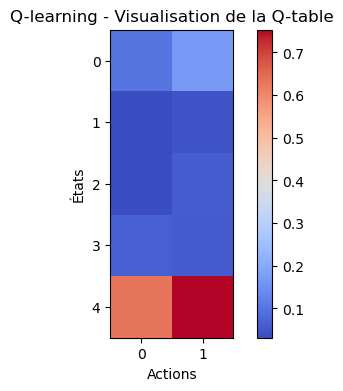

In [19]:
#Q-learning (apprentissage par renforcement)
import numpy as np
# Importation de numpy pour manipuler
# les tableaux numériques et la matrice Q.

# ================================
# 1. Initialisation de la Q-table
# ================================

Q = np.zeros((5, 2))
# Création de la Q-table :

# - 5 états possibles
# - 2 actions possibles
#
# Chaque cellule Q[state, action]
# contient la valeur estimée d’une action
# dans un état donné.

# Au début, toutes les valeurs sont à 0
# car l’agent ne connaît encore rien.

# ================================
# 2. Paramètres du modèle
# ================================

learning_rate = 0.1
# Taux d’apprentissage.

# Il contrôle la vitesse de mise à jour
# des connaissances de l’agent.

# Petite valeur → apprentissage lent mais stable.
# Grande valeur → apprentissage rapide mais instable.

gamma = 0.9
# Facteur de réduction (discount factor).

# Il mesure l’importance des récompenses futures.

# gamma proche de 1 :
# l’agent pense au long terme.

episodes = 100
# Nombre d’épisodes d’apprentissage.

# Chaque épisode représente une nouvelle tentative
# d’exploration de l’environnement.

# ================================
# 3. Phase d’apprentissage
# ================================

for episode in range(episodes):

    state = np.random.randint(0, 5)
    # Choix aléatoire d’un état initial.
    
    # Ici les états vont de 0 à 4.

    action = np.random.randint(0, 2)
    # Choix aléatoire d’une action.
    
    # Deux actions possibles :
    # action 0 ou action 1.

    reward = 1 if state == 4 else 0
    # Système de récompense :
    
    # si l’agent atteint l’état 4 :
    # récompense positive = 1
    
    # sinon :
    # récompense = 0

    next_state = np.random.randint(0, 5)
    # Simulation d’un nouvel état
    # après l’action choisie.

    Q[state, action] = Q[state, action] + learning_rate * (
        reward + gamma * np.max(Q[next_state]) - Q[state, action]
    )
    # Mise à jour de la Q-table selon l’équation de Q-learning.
    
    # Le modèle combine :
    # - la récompense immédiate
    # - la meilleure récompense future possible
    
    # Cela permet à l’agent
    # d’améliorer progressivement ses décisions.

# ================================
# 4. Résultat final
# ================================

print("Q-table finale :")
print(Q)
# Affichage des connaissances apprises.
#
# Les grandes valeurs représentent
# les meilleures actions à effectuer
# dans chaque état.

# ================================
# 5. Graphe de la Q-table
# ================================

plt.figure(figsize=(6,4))
# Création d’une figure pour afficher le graphique
# figsize définit la taille du graphique

plt.imshow(Q, cmap="coolwarm")
# Affichage de la Q-table sous forme de carte de couleurs
# Chaque case représente une valeur Q (qualité d’une action)
# bleu = faible valeur, rouge = grande valeur

plt.colorbar()
# Ajoute une barre de couleurs pour interpréter les valeurs

plt.xlabel("Actions")
# Axe horizontal : les actions possibles

plt.ylabel("États")
# Axe vertical : les états possibles

plt.title("Q-learning - Visualisation de la Q-table")
# Titre du graphique

plt.show()
# Affiche le graphique final